# Model Architecture

The implemented model leverages a Transformer architecture for sentiment analysis. The Transformer block consists of multiple self-attention mechanisms applied iteratively (num_heads). Each attention mechanism captures different aspects of the input sequence, allowing the model to efficiently learn complex patterns. A subsequent 1D convolutional layer is employed to capture local patterns, followed by global average pooling for dimensionality reduction. Dropout is used for regularization, and the final layers include a dense layer with ReLU activation and a sigmoid activation for binary sentiment classification.

## Step 1: Importing Libraries

In [82]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Attention, LayerNormalization, Dropout

## Step 2: Load the Dataset
Reads the IMDB dataset from a CSV file using Pandas and stores it in a DataFrame (df).




In [83]:
import kagglehub
import pandas as pd
import numpy as np


import kagglehub
path = kagglehub.dataset_download("haisemei/fact-checking-dataset-label")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\juanj\.cache\kagglehub\datasets\haisemei\fact-checking-dataset-label\versions\3


In [84]:
file = path + '\HIGH_CONFIDENCE_train_dataset.json'
data = pd.read_json(file)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\juanj\AppData\Local\Temp\ipykernel_3120\2382318628.py:1: SyntaxWarning: invalid escape sequence '\H'
  file = path + '\HIGH_CONFIDENCE_train_dataset.json'


,claim,label,contexts
0,"So với cùng kỳ năm 2024, số vụ tai nạn giao th...",REFUTED,"[Sau 3 tháng thực thi nghị định 168, số vi phạ..."
1,"Từ ngày 15/9 đến 14/12, xe tải và xe khách từ ...",SUPPORTED,[Trên cao tốc Pháp Vân - Cầu Giẽ (từ km182+300...
2,"Benny, chủ tiệm kim hoàn trên phố Broadway, ch...",NEI,"[Vụ cướp Theo thông tin ban đầu, đây là tiệm v..."
3,Liên danh Đèo Cả - Văn Phú đã cam kết tự bố tr...,NEI,"[Tổng chiều dài khoảng 80,5km (Hữu Hồng 44,8km..."
4,"Vào năm 2024, số người thất nghiệp ở Đức đã gi...",NEI,[California tuyên bố chính thức vượt qua Nhật ...


In [85]:
# Encode label
def encode_label(row):
    if row['label'] == 'SUPPORTED':
        return 1
    elif row['label'] == 'NEI':
        return 0
    elif row['label'] == 'REFUTED':
        return 0

# Acá se prepara el texto concatenando claim y contexts con separadores
def concat_claim_evidence(row):
    return '[CLS] Claim: ' + row['claim'] + " [SEP] Context: " + " ".join(row['contexts'])

data['label'] = data.apply(encode_label, axis = 1)
data['fact'] = data.apply(concat_claim_evidence, axis = 1)
df = data.copy()
df.head()

,claim,label,contexts,fact
0,"So với cùng kỳ năm 2024, số vụ tai nạn giao th...",0,"[Sau 3 tháng thực thi nghị định 168, số vi phạ...","[CLS] Claim: So với cùng kỳ năm 2024, số vụ ta..."
1,"Từ ngày 15/9 đến 14/12, xe tải và xe khách từ ...",1,[Trên cao tốc Pháp Vân - Cầu Giẽ (từ km182+300...,"[CLS] Claim: Từ ngày 15/9 đến 14/12, xe tải và..."
2,"Benny, chủ tiệm kim hoàn trên phố Broadway, ch...",0,"[Vụ cướp Theo thông tin ban đầu, đây là tiệm v...","[CLS] Claim: Benny, chủ tiệm kim hoàn trên phố..."
3,Liên danh Đèo Cả - Văn Phú đã cam kết tự bố tr...,0,"[Tổng chiều dài khoảng 80,5km (Hữu Hồng 44,8km...",[CLS] Claim: Liên danh Đèo Cả - Văn Phú đã cam...
4,"Vào năm 2024, số người thất nghiệp ở Đức đã gi...",0,[California tuyên bố chính thức vượt qua Nhật ...,"[CLS] Claim: Vào năm 2024, số người thất nghiệ..."


## Step 3: Data Cleaning and Preprocessing

* Cleans and preprocesses the text data in the 'review' column.
* Removes non-alphabetic characters.
* Converts text to lowercase.
* Removes stopwords using NLTK.

In [86]:
# df['fact'] = df['fact'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
# df['fact'] = df['fact'].apply(lambda x: x.lower())
# nltk.download('stopwords')
# stop_words = set(stopwords.words('english'))
# df['fact'] = df['fact'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

## Step 4: Data Splitting
Splits the dataset into training and testing sets using the train_test_split function from scikit-learn.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(df['fact'], df['label'], test_size=0.8, random_state=42)

### Undersampling

<BarContainer object of 2 artists>

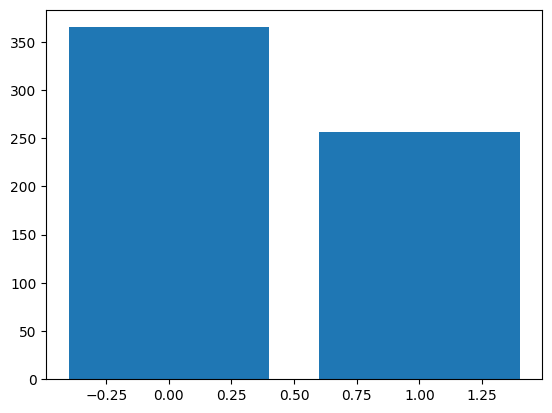

In [88]:
import matplotlib.pyplot as plt
balance = y_train.value_counts().to_frame().reset_index()
plt.bar(balance['label'], height=balance['count'])

In [89]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42, replacement=False, sampling_strategy='not minority')
X_train, y_train = rus.fit_resample(X_train.to_frame(), y_train.to_frame())

<BarContainer object of 2 artists>

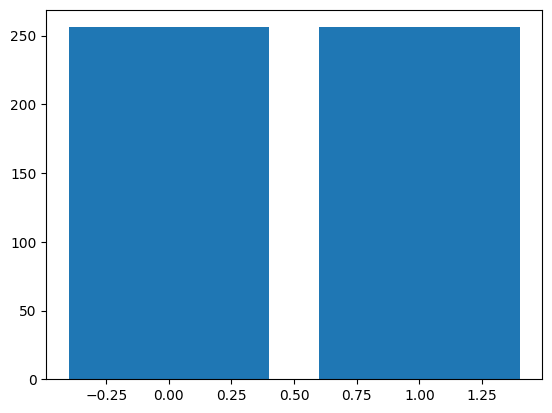

In [90]:
import matplotlib.pyplot as plt
balance = y_train.value_counts().to_frame().reset_index()
plt.bar(balance['label'], height=balance['count'])

In [91]:
# Turn train data into pd.Series again...
y_train = y_train['label']
X_train = X_train['fact']

##Step 5: Label Encoding for Sentiment Column
Encodes the categorical 'sentiment' labels into numerical format using LabelEncoder.



In [92]:
# Label Encoding for Sentiment Column
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

## Step 6: Tokenization and Padding
Tokenizes and pads the text sequences for input into a neural network using Keras's Tokenizer and pad_sequences.


In [93]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)
X_train_padded = pad_sequences(X_train_sequences, maxlen=1000, truncating='post', padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=1000, truncating='post', padding='post')

In [94]:
X_test_padded

array([[ 174,  175, 2274, ...,    0,    0,    0],
       [ 174,  175,  911, ...,    0,    0,    0],
       [ 174,  175,   22, ...,    0,    0,    0],
       ...,
       [ 174,  175, 1281, ...,    0,    0,    0],
       [ 174,  175,   22, ...,    0,    0,    0],
       [ 174,  175,  140, ...,    0,    0,    0]],
      shape=(2485, 1000), dtype=int32)

In [95]:
y_test_encoded

array([0, 0, 0, ..., 1, 1, 1], shape=(2485,))

## Step 7: Transformer Model Building
Defines a Transformer model architecture using Keras. It includes an embedding layer, a Transformer block with attention mechanisms, convolutional and pooling layers, and final dense layers.


In [96]:
# Transformer Model Building
embedding_dim = 32  # We can Adjust the embedding dimension based on our preference
num_heads = 2
ff_dim = 32

inputs = Input(shape=(1000,))
embedding_layer = Embedding(input_dim=10000, output_dim=embedding_dim)(inputs)
transformer_block = embedding_layer

for _ in range(num_heads):
    attn_output = Attention(use_scale=True)([transformer_block, transformer_block])
    transformer_block = LayerNormalization(epsilon=1e-6)(transformer_block + attn_output)
    transformer_block = Dropout(0.1)(transformer_block)

transformer_block = tf.keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(transformer_block)
transformer_block = tf.keras.layers.GlobalAveragePooling1D()(transformer_block)
transformer_block = Dropout(0.1)(transformer_block)
transformer_block = Dense(20, activation='relu')(transformer_block)
output_layer = Dense(2, activation='softmax')(transformer_block)

model = Model(inputs=inputs, outputs=output_layer)

## Step 8: Model Training
Compiles and trains the Transformer model on the training data for 5 epochs.


In [97]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_padded, y_train_encoded, epochs=100, validation_data=(X_test_padded, y_test_encoded))

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5117 - loss: 0.7039 - val_accuracy: 0.6080 - val_loss: 0.6731
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 623ms/step - accuracy: 0.5488 - loss: 0.6866 - val_accuracy: 0.5674 - val_loss: 0.6882
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 564ms/step - accuracy: 0.5898 - loss: 0.6756 - val_accuracy: 0.4805 - val_loss: 0.7049
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 554ms/step - accuracy: 0.6191 - loss: 0.6552 - val_accuracy: 0.5445 - val_loss: 0.6923
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 583ms/step - accuracy: 0.6641 - loss: 0.6179 - val_accuracy: 0.5545 - val_loss: 0.6937
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 578ms/step - accuracy: 0.7109 - loss: 0.5771 - val_accuracy: 0.6270 - val_loss: 0.6610
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 537ms/step - accuracy: 0.7051 - loss: 0.5508 - val_accuracy: 0.4644 - val_loss: 0.7876
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 532ms/step - accuracy: 0.7168 - loss: 0.5341 - val_accur

##Step 9: Save the Model
Saves the trained model in the HDF5 format for future use (while developing an app and its deployment)



In [98]:
model.save('model.keras')

## Step 10: Evaluate the Model
Evaluates the model on the test set, computes accuracy, and generates a classification report.


In [99]:
y_pred_prob = model.predict(X_test_padded)

y_pred = np.array([x.argmax() for x in y_pred_prob])

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step
Accuracy: 0.5951710261569416
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.70      0.68      1511
           1       0.48      0.44      0.46       974

    accuracy                           0.60      2485
   macro avg       0.57      0.57      0.57      2485
weighted avg       0.59      0.60      0.59      2485



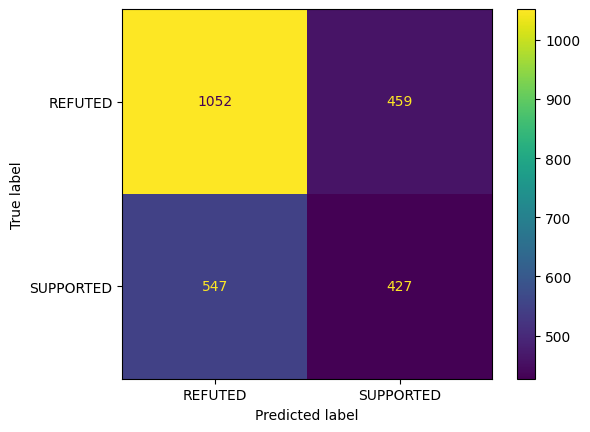

In [100]:
from sklearn import metrics
import matplotlib.pyplot as plt

confusion_matrix = metrics.confusion_matrix(y_test_encoded, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['REFUTED', 'SUPPORTED'])
cm_display.plot()
plt.show()

## Step 11: User Input Prediction
Defines a function for predicting sentiment based on user input and prompts the user to input a review for sentiment prediction.


In [101]:
# User Input Prediction
def predict_sentiment_transformer(comment):
    labels_encoding = {
        0: 'REFUTED',
        1: 'SUPPORTED',
    }

    cleaned_comment = comment.lower()
    sequence = tokenizer.texts_to_sequences([cleaned_comment])
    padded_sequence = pad_sequences(sequence, maxlen=1000, truncating='post', padding='post')
    prediction = model.predict(padded_sequence)
    print(prediction)
    return labels_encoding[prediction.argmax()]

# Enter your review to get the prediction of the sentiment
user_input = input("Enter your Review here: ")
prediction = predict_sentiment_transformer(user_input)
print(f"Predicted Sentiment: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[0.00122523 0.9987747 ]]
Predicted Sentiment: SUPPORTED


In [ ]:

import ast

comment = {
    "claim": "Từ ngày 15/9 đến 14/12, xe tải và xe khách từ 9 chỗ ngồi trở lên bị cấm đi trên làn trong cùng sát dải phân cách giữa trên cao tốc Hà Nội - Hải Phòng và Pháp Vân - Cầu Giẽ.",
    "label": "SUPPORTED",
    "contexts": [
      "Trên cao tốc Pháp Vân - Cầu Giẽ (từ km182+300 đến km211+250) đối với làn trái trong cùng sát dải phân cách (làn 1) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 80km/h, cấm ô tô tải hoạt động trên làn này.\n\nTại làn giữa sát làn trái trong cùng (làn 2) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 70km/h, các ô tô đều hoạt động.\n\nĐối với làn ngoài cùng sát làn dừng khẩn cấp (làn 3) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 60km/h, các ô tô đều hoạt động.\n\nTại giai đoạn 2, sẽ tổ chức phân làn tốc độ và phân luồng phương tiện đối với xe tải, xe khách\n\nTrên cao tốc Hà Nội - Hải Phòng giữ nguyên việc phân làn tốc độ như giai đoạn 1 nhưng cấm xe tải, xe khách hoạt động trên làn trái trong cùng sát dải phân cách (làn 1).\n\nĐối với cao tốc Pháp Vân - Cầu Giẽ giữ nguyên việc phân làn tốc độ như giai đoạn 1 nhưng cấm xe tải, xe khách hoạt động trên làn trái trong cùng sát dải phân cách (làn 1).\n\nCứ 3 vụ tai nạn thì có 1 vụ liên quan đến xe kinh doanh vận tải",
      "Liên quan tới việc Cục CSGT (C08, Bộ Công an) đề xuất thí điểm tổ chức phân làn cấm xe tải, xe khách đi vào làn sát dải phân cách (làn tốc độ cao nhất) trên cao tốc Hà Nội - Hải Phòng và Pháp Vân - Cầu Giẽ, sáng 5/8, trao đổi với phóng viên  Dân trí,  Đại tá Nguyễn Quang Nhật, Trưởng Phòng Hướng dẫn tuyên truyền, điều tra, giải quyết tai nạn giao thông, Cục C08 đã có lý giải về đề xuất này.\n\nLý do đề xuất cấm xe tải, xe khách\n\nTheo Đại tá Nhật, có 3 nguyên nhân chính như sau: Trong thời gian qua, tình hình trật tự an toàn giao thông và tai nạn giao thông liên quan đến xe tải, xe khách tăng cao, chiếm 1/3 tổng số vụ tai nạn giao thông trong 6 tháng đầu năm.\n\nMột chiếc ô tô khách đi ngược chiều trên cao tốc Hà Nội - Hải Phòng (Ảnh: Đức Phúc).\n\nThứ hai, ý thức tham gia giao thông của người lái xe kinh doanh vận tải còn hạn chế, cá biệt có một số trường hợp cố tình vi phạm như điều khiển phương tiện tốc độ thấp đi ở làn đường tốc độ cao, đặc biệt là xe tải lớn, xe container.",
      "Tại giai đoạn 1, sẽ tổ chức phân làn tốc độ và phân luồng phương tiện đối với xe tải\nĐối với tuyến cao tốc Hà Nội - Hải Phòng (từ Km0+000 đến Km105+417): Thực hiện tổ chức giao thông phân làn tốc độ, phân luồng phương tiện trên một chiều đường như sau:\n- Đối với làn trái trong cùng sát dải phân cách (Làn 1) quy định tốc độ tối đa 120 km/giờ, tốc độ tối thiểu 90 km/giờ, cấm xe ôtô tải hoạt động trên làn này;\n- Đối với làn giữa sát làn trái trong cùng (Làn 2) quy định tốc độ tối đa 100 km/giờ, tốc độ tối thiểu 80 km/giờ, các xe ôtô đều hoạt động trên làn;\n- Đối với làn ngoài cùng sát làn dừng khẩn cấp (Làn 3) quy định tốc độ tối đa 100 km/giờ, tốc độ tối thiểu 60 km/giờ, các xe ôtô đều hoạt động trên làn."
    ]
  }

comment = ast.literal_eval(comment)
cleaned_comment = '[CLS] Claim: ' + comment['claim'] + " [SEP] Context: " + " ".join(comment['contexts'])
cleaned_comment

'[CLS] Claim: Từ ngày 15/9 đến 14/12, xe tải và xe khách từ 9 chỗ ngồi trở lên bị cấm đi trên làn trong cùng sát dải phân cách giữa trên cao tốc Hà Nội - Hải Phòng và Pháp Vân - Cầu Giẽ. [SEP] Context: Trên cao tốc Pháp Vân - Cầu Giẽ (từ km182+300 đến km211+250) đối với làn trái trong cùng sát dải phân cách (làn 1) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 80km/h, cấm ô tô tải hoạt động trên làn này.\n\nTại làn giữa sát làn trái trong cùng (làn 2) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 70km/h, các ô tô đều hoạt động.\n\nĐối với làn ngoài cùng sát làn dừng khẩn cấp (làn 3) quy định tốc độ tối đa 100km/h, tốc độ tối thiểu 60km/h, các ô tô đều hoạt động.\n\nTại giai đoạn 2, sẽ tổ chức phân làn tốc độ và phân luồng phương tiện đối với xe tải, xe khách\n\nTrên cao tốc Hà Nội - Hải Phòng giữ nguyên việc phân làn tốc độ như giai đoạn 1 nhưng cấm xe tải, xe khách hoạt động trên làn trái trong cùng sát dải phân cách (làn 1).\n\nĐối với cao tốc Pháp Vân - Cầu Giẽ giữ nguyên việc